# Analisi di visibilità
> L'analisi di visibilità è un argomento molto interessante da trattare con Python. In un mio articolo l'ho affrontata usando QGIS, qui oggi vediamo come raggiungere lo stesso obiettivo con Python.

- toc: true
- badges: true
- comments: false
- author: Massimiliano Moraca
- categories: [point, raster]
- image: images/logo.png

L’analisi di visibilità è un argomento molto interessante da trattare con Python. In un [mio articolo](https://massimilianomoraca.it/blog/gis/analisi-di-visibilita/) l’ho affrontata usando QGIS, qui oggi vediamo come raggiungere lo stesso obiettivo con Python.

## Prima di iniziare


### Librerie
Per raggiungere l'obiettivo userò .....


In [9]:
import pathlib

import geopandas as gpd
import rioxarray as rxr

import rasterio as rio
from rasterio.plot import show, show_hist
import matplotlib.pyplot as plt

### Fonti dati
Come [DEM](https://massimilianomoraca.it/blog/gis/3d-open-source/) ho usato un ritaglio del progetto [DEM20 di ISPRA](http://www.sinanet.isprambiente.it/it/sia-ispra/download-mais/dem20/view) su cui ho posizionato con QGIS undici punti; nell'articolo del blog uso l'undicesimo, qui provò ad usarli tutti'.

In [2]:
sample_data = pathlib.Path.cwd().parent.joinpath('sample_data/viewshed')
dem = sample_data.joinpath('ispra_dtm_20.tif')
points = sample_data.joinpath('poi.shp')

# 1. Lettura dei dati

In [3]:
point_data = gpd.read_file(points)
point_data

,fid,geometry
0,1,POINT (458757.920 4498413.572)
1,2,POINT (462111.858 4502990.699)
2,3,POINT (459359.399 4506106.798)
3,4,POINT (457577.922 4495996.256)
4,5,POINT (447422.726 4500303.775)
5,6,POINT (461931.392 4502754.454)
6,7,POINT (464694.875 4495428.963)
7,8,POINT (457380.393 4500985.601)
8,9,POINT (452798.980 4493684.317)
9,10,POINT (455753.530 4496944.529)


In [5]:
raster = rxr.open_rasterio(dem)
raster

<xarray.DataArray (band: 1, y: 1176, x: 1464)>
[1721664 values with dtype=int16]
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 4.386e+05 4.387e+05 ... 4.679e+05 4.679e+05
  * y            (y) float64 4.513e+06 4.513e+06 ... 4.489e+06 4.489e+06
    spatial_ref  int64 0
Attributes:
    _FillValue:    -32768.0
    scale_factor:  1.0
    add_offset:    0.0

Il vettore dei punti è molto semplice, ha una colonna con le geometrie ed una che identifica il singolo punto; quest'ultima informazione la userò più avanti. Il DEM è rettangolare e monobanda ed in effetti mi aspetto che sia monobanda poichè è quella che contiene le informazioni altimetriche in questo caso.

## 1.1 Visualizzazione dei dati grezzi

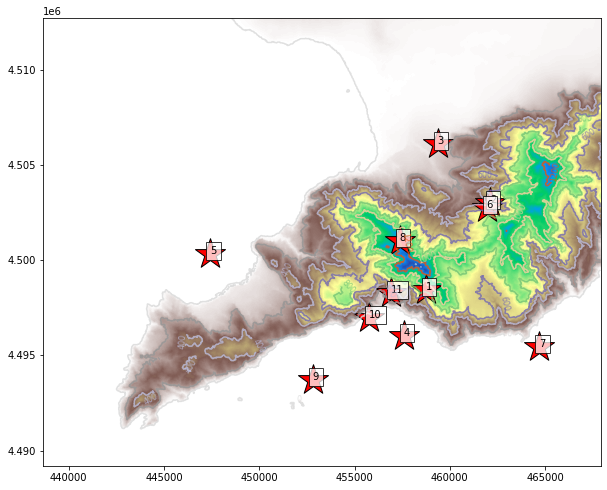

In [81]:
raster_data = rio.open(dem)

fig, ax = plt.subplots(figsize=(10, 10))
show(
    source=raster_data,
    cmap='tab20c_r',
    contour=True,
    ax=ax,
    transform=raster_data.transform
)
show(
    source=raster_data,
    cmap='terrain_r',
    ax=ax,
    transform=raster_data.transform
)
for _index, row in point_data.iterrows():
    coordinates = row.geometry.xy
    ax.scatter(
        *coordinates,
        s=1000,
        marker="*",
        facecolor='red',
        edgecolor='black'
    )
    plt.text(
        x=coordinates[0][0],
        y=coordinates[1][0],
        s=row.fid,
        fontdict=dict(color='black', size=10),
        bbox=dict(facecolor='white', alpha=0.75)
    )
plt.show()